In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

base_path = Path("/content/drive/MyDrive/wyzwanie-aiml/1/")

# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

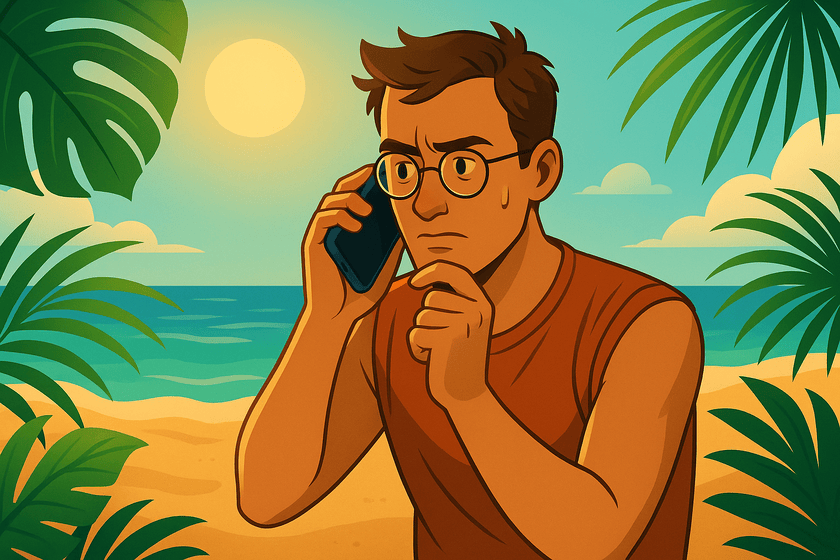

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |


In [33]:
df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')
df.Survived.value_counts(normalize=True)
df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

1. PODSTAWOWE INFO

In [34]:
print(f'wiersze: {df.shape[0]}, kolumny: {df.shape[1]}')

df.head()
df.info()
df.describe(include='all')


def showmissing(data):
    missing = data.isnull().sum()
    percent = (missing/len(data)*100)
    table = pd.DataFrame({'brakujace': missing, 'procent': percent})
    return table[table['brakujace'] > 0].sort_values(
        'brakujace', ascending=False)


showmissing(df)


wiersze: 891, kolumny: 11
<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      793 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


,brakujace,procent
Cabin,687,77.104377
Age,177,19.865320
Fare,98,10.998878
Embarked,2,0.224467


dla znacznej wiekszosci pasazerow nie wiadomy jest nr ich kabiny, dla 1/5 nie mozna ustalic ich wieku, a dla dwoch nie ma zapisanego portu gdzie weszli na poklad

2. UZUPELNIENE BRAKOW I ANALIZA

In [35]:
freqtitles = ['Mr', 'Miss', 'Mrs', 'Master']


def gettitle(name):
    title = name.split(',')[1].split('.')[0].strip()
    if title in freqtitles:
        return title
    return 'Rare'


df['Title'] = df['Name'].apply(gettitle)
print(df['Title'].value_counts())

df['FamilySize'] = df['SibSp']+df['Parch']+1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
print(df[['FamilySize', 'IsAlone']].value_counts())


Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64
FamilySize  IsAlone
1           1          537
2           0          161
3           0          102
4           0           29
6           0           22
5           0           15
7           0           12
11          0            7
8           0            6
Name: count, dtype: int64


In [36]:
def fillage(row, median):
    if pd.isnull(row['Age']):
        return median.loc[row['Pclass'], row['Sex']]
    return row['Age']


agemedian = df.groupby(['Pclass', 'Sex'])['Age'].median()
print('mediany wieku:')
print(agemedian)

df['Age'] = df.apply(fillage, axis=1, args=(agemedian,))


mediany wieku:
Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64


In [37]:
faremedian = df.groupby('Pclass')['Fare'].median()


def fillfare(row, median):
    if pd.isnull(row['Fare']):
        return median.loc[row['Pclass']]
    return row['Fare']


df['Fare'] = df.apply(fillfare, axis=1, args=(faremedian,))


modeembarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(modeembarked)
print(f'moda Embarked: {modeembarked}')


def getdeck(cabine):
    if pd.notnull(cabine):
        return cabine[0]
    return 'U'


df['Deck'] = df['Cabin'].apply(getdeck)
print(df['Deck'].value_counts())


moda Embarked: S
Deck
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64


In [38]:
print(
    f'braki po uzupelnieniu? {df[["Age", "Fare", "Embarked"]].isnull().sum().sum()}')

print('braki po uzupelnieniu?')
print(showmissing(df))

deletedcolumns = ['Name', 'Ticket', 'Cabin']
df = df.drop(columns=deletedcolumns)
print(f'kolumby {list(df.columns)}')


braki po uzupelnieniu? 0
braki po uzupelnieniu?
       brakujace    procent
Cabin        687  77.104377
kolumby ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'Deck']


3. kodowanie cech (kategorii):

    Sex -> label encoding (0 1)
        
    Emabrked, Title, Deck -> one hot encoding

    Pclass -> pozostawione jako liczba

In [39]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

df = pd.get_dummies(df, columns=['Embarked', 'Title', 'Deck'], drop_first=True)

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print(f'kolumny po: {df.shape[1]}')
df.head(3)


kolumny po: 23


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Embarked_Q,...,Title_Mrs,Title_Rare,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U
PassengerId,,,,,,,,,,,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,2,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1,1,1,38.0,1,0,71.2833,2,0,0,...,1,0,0,1,0,0,0,0,0,0
3,1,3,1,26.0,0,0,7.9250,1,1,0,...,0,0,0,0,0,0,0,0,0,1


3. AANALIZA Z WYKRESAMI

zmienn predykowana Survived:

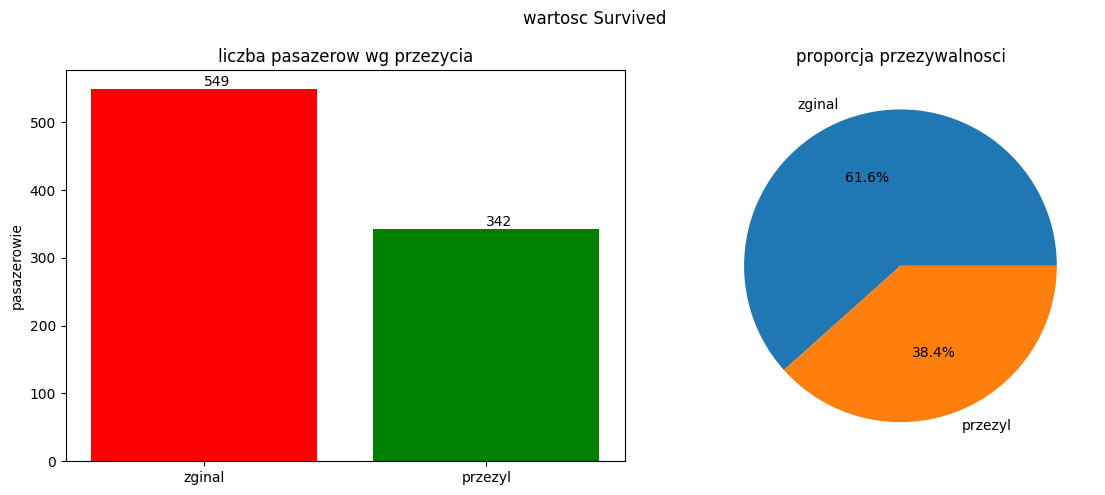

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['Survived'].value_counts()
axes[0].bar(['zginal', 'przezyl'], counts.values, color=['red', 'green'])
axes[0].set_title('liczba pasazerow wg przezycia')
axes[0].set_ylabel('pasazerowie')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+5, str(v))

axes[1].pie(counts.values, labels=['zginal', 'przezyl'], autopct='%1.1f%%', )
axes[1].set_title('proporcja przezywalnosci')

plt.suptitle('wartosc Survived')
plt.tight_layout()
plt.show()


zbiór jest niezbalansowany (38% vs 62% przezylo/nieprzezylo)

rozklady cech liczbowych:

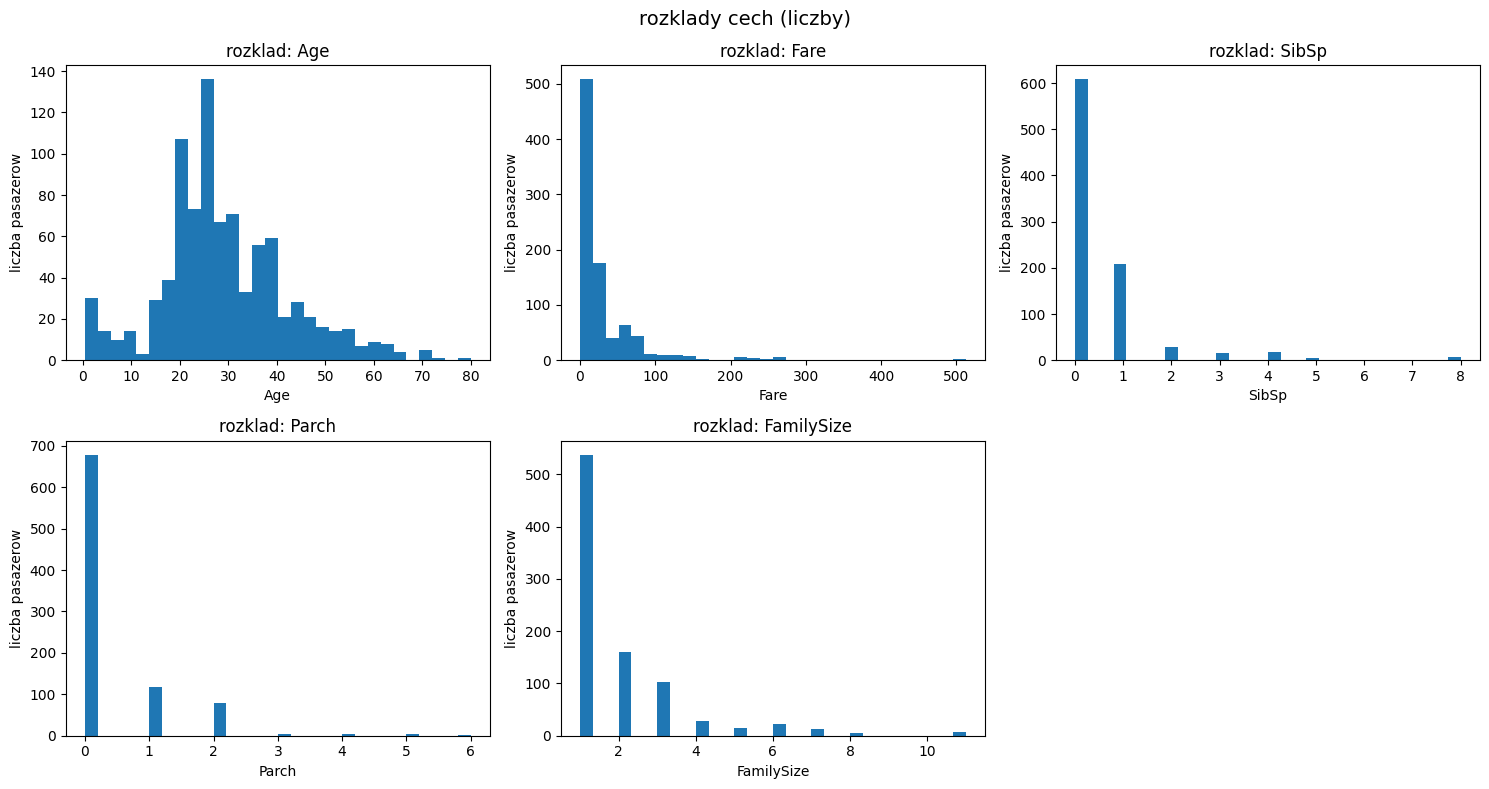

In [41]:
numbervalues = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, value in enumerate(numbervalues):
    axes[i].hist(df[value], bins=30)
    axes[i].set_title(f'rozklad: {value}')
    axes[i].set_xlabel(value)
    axes[i].set_ylabel('liczba pasazerow')

axes[-1].set_visible(False)
plt.suptitle('rozklady cech (liczby)', fontsize=14)
plt.tight_layout()
plt.show()


Age w miare przypomina rozklad normalny, szczyt widac miedzy 20 a 30 lat

W Fare widac ze kilku pasazerow mialo dorgie bilety

outliery metoda iqr:



               Q1      Q3     IQR  dolna granica  gorna granica  liczba outlierow
Age         21.50  36.000  14.500        -0.2500        57.7500              33.0
Fare         8.05  31.275  23.225       -26.7875        66.1125             105.0
SibSp        0.00   1.000   1.000        -1.5000         2.5000              46.0
Parch        0.00   0.000   0.000         0.0000         0.0000             213.0
FamilySize   1.00   2.000   1.000        -0.5000         3.5000              91.0




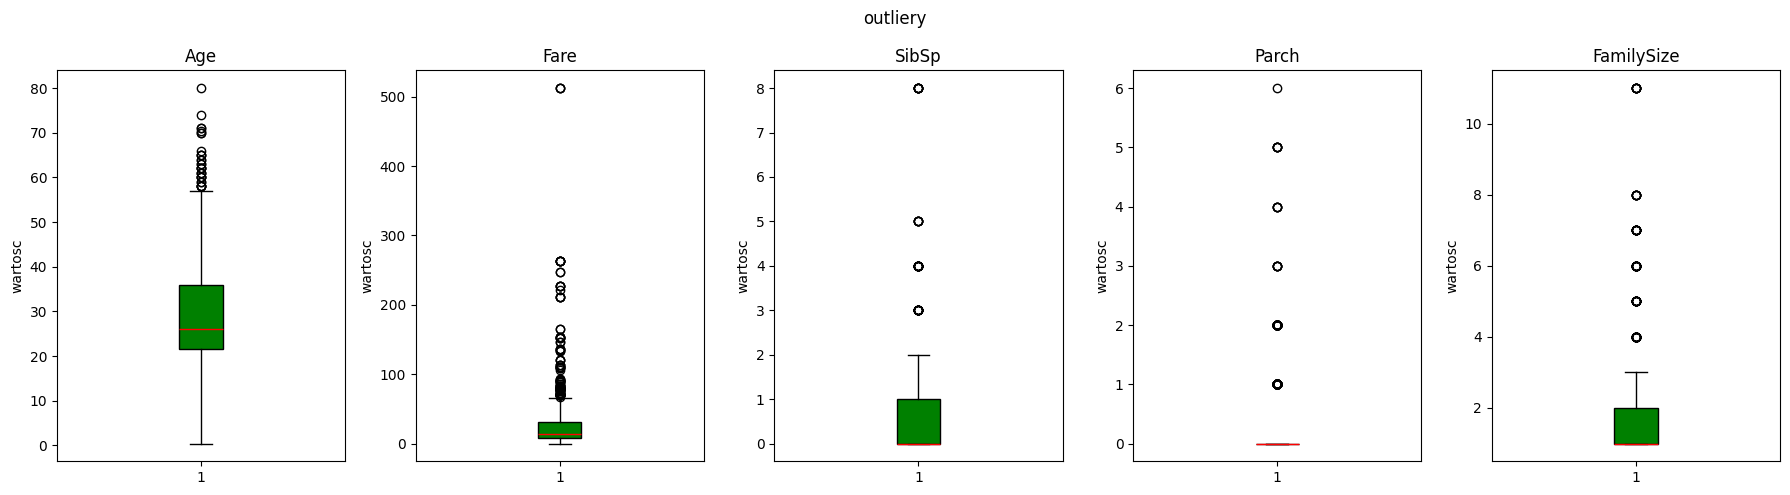

In [42]:
def detectoutliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3-Q1
    bottom = Q1-1.5*IQR
    top = Q3+1.5*IQR
    outliers = ((series < bottom) | (series > top)).sum()
    return pd.Series({'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'dolna granica': bottom,
                     'gorna granica': top, 'liczba outlierow': outliers})


print('\n')
results = pd.DataFrame({c: detectoutliers(df[c]) for c in numbervalues}).T
print(results.to_string())
print('\n')

fig, axes = plt.subplots(1, len(numbervalues), figsize=(18, 5))
for i, value in enumerate(numbervalues):
    axes[i].boxplot(
        df[value],
        patch_artist=True,
        boxprops=dict(
            facecolor='green',
            color='black'),
        medianprops=dict(
            color='red'))
    axes[i].set_title(value)
    axes[i].set_ylabel('wartosc')
plt.suptitle('outliery')
plt.tight_layout()
plt.show()


ponownie widac pojedyncze drogie bilety w Fare

podobnie w przypadku pojedynczych bardzo licznych rodzin

przezywalnocsc wg cech (kategorii):

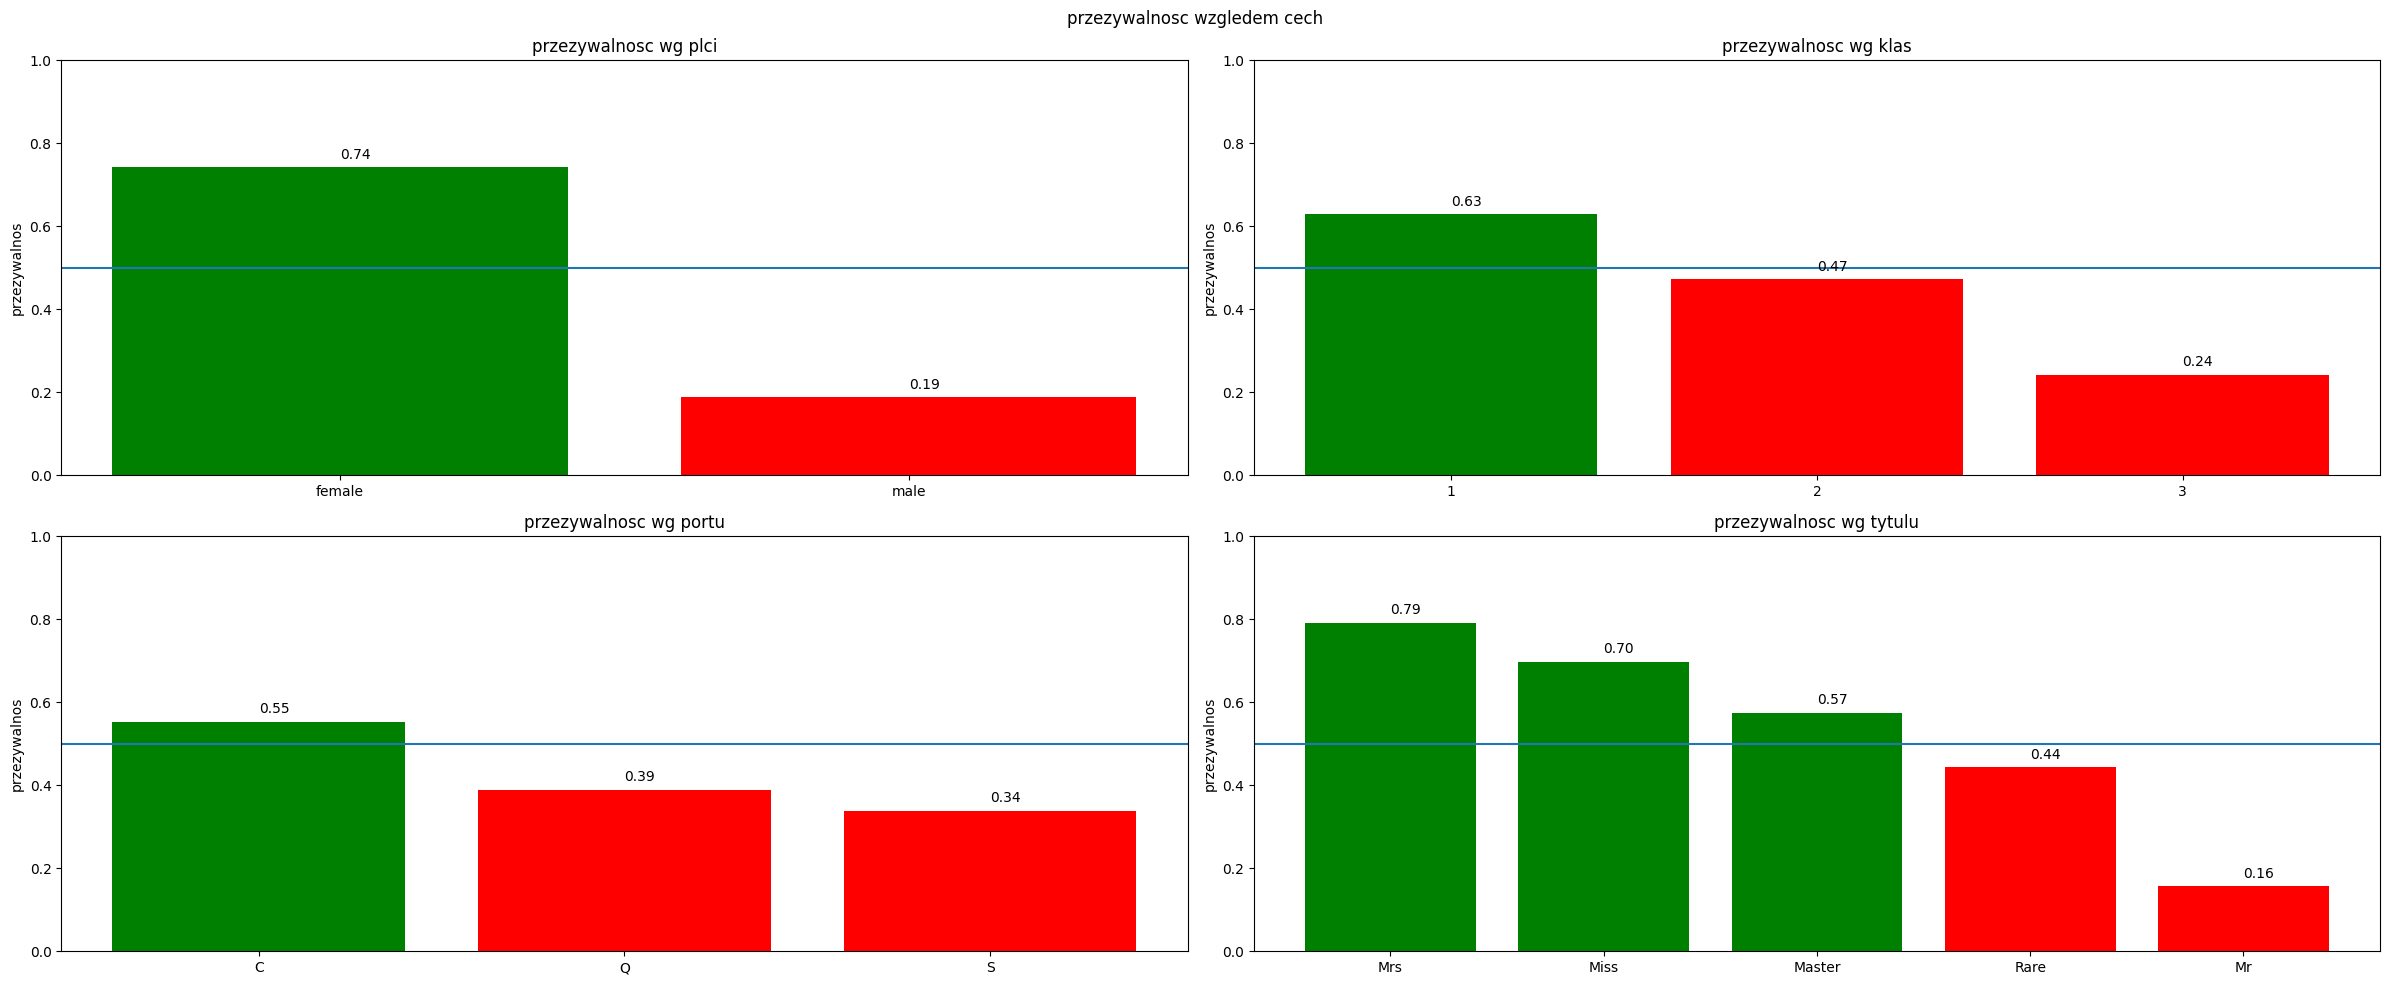

In [43]:
dforig = pd.read_csv(base_path / 'titanic.csv')
dforig['Title'] = dforig['Name'].apply(gettitle)
dforig['FamilySize'] = dforig['SibSp']+dforig['Parch'] + 1
dforig['IsAlone'] = (dforig['FamilySize'] == 1).astype(int)
dforig['Embarked'] = dforig['Embarked'].fillna(modeembarked)


def survivabilitychart(data, value, ax, title=None):
    table = data.groupby(value)['Survived'].mean().sort_values(ascending=False)
    colors = ['green' if v > 0.5 else 'red' for v in table.values]
    ax.bar(table.index.astype(str), table.values, color=colors)
    ax.set_ylim(0, 1)
    ax.set_ylabel('przezywalnos')
    ax.set_title(title or f'przezywalnosc wg {value}')
    ax.axhline(0.5)
    for j, (k, v) in enumerate(table.items()):
        ax.text(j, v+0.02, f'{v:.2f}',)


fig, axes = plt.subplots(2, 2, figsize=(24, 10))
survivabilitychart(dforig, 'Sex', axes[0, 0], 'przezywalnosc wg plci')
survivabilitychart(dforig, 'Pclass', axes[0, 1], 'przezywalnosc wg klas')
survivabilitychart(dforig, 'Embarked', axes[1, 0], 'przezywalnosc wg portu')
survivabilitychart(dforig, 'Title', axes[1, 1], 'przezywalnosc wg tytulu')
plt.suptitle('przezywalnosc wzgledem cech')
plt.tight_layout()
plt.show()


przezylo 74% kobiet i tlyko 19% mezczyzn (podobne wyniki dla Miss/Mrs oraz Mr)

z I klasy uratowalo sie 63%, II 47% a z III juz tylko 24%

ponadto widac ze z portu Cherbourg przezylo az 55%, prawdopodobnie tam wsiadlo duzo osob z I klasy

przezywalnosc wg cech (liczby):

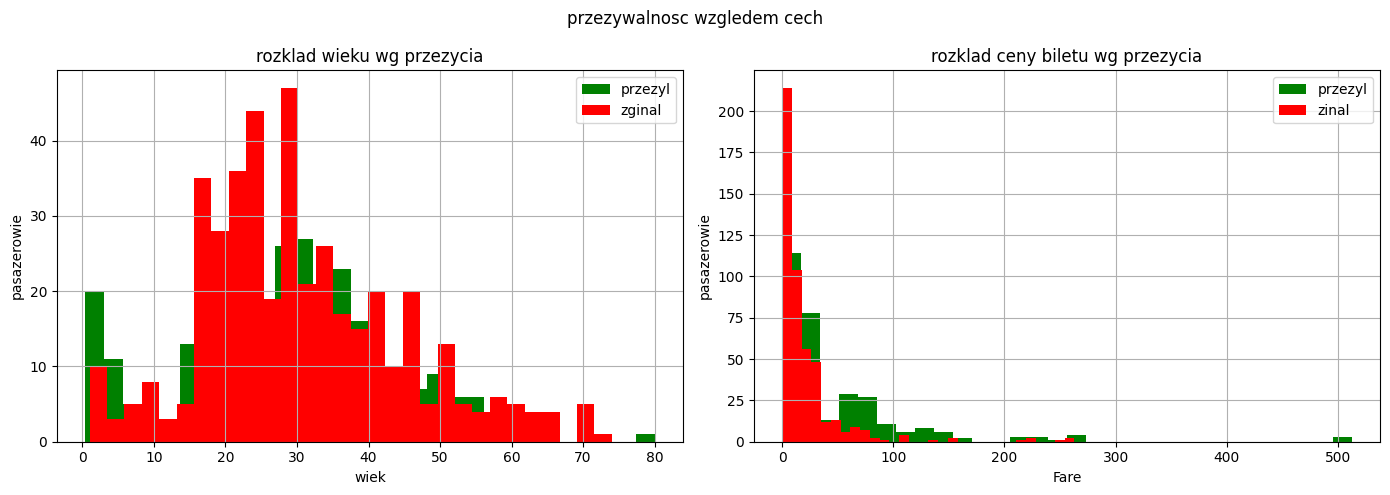

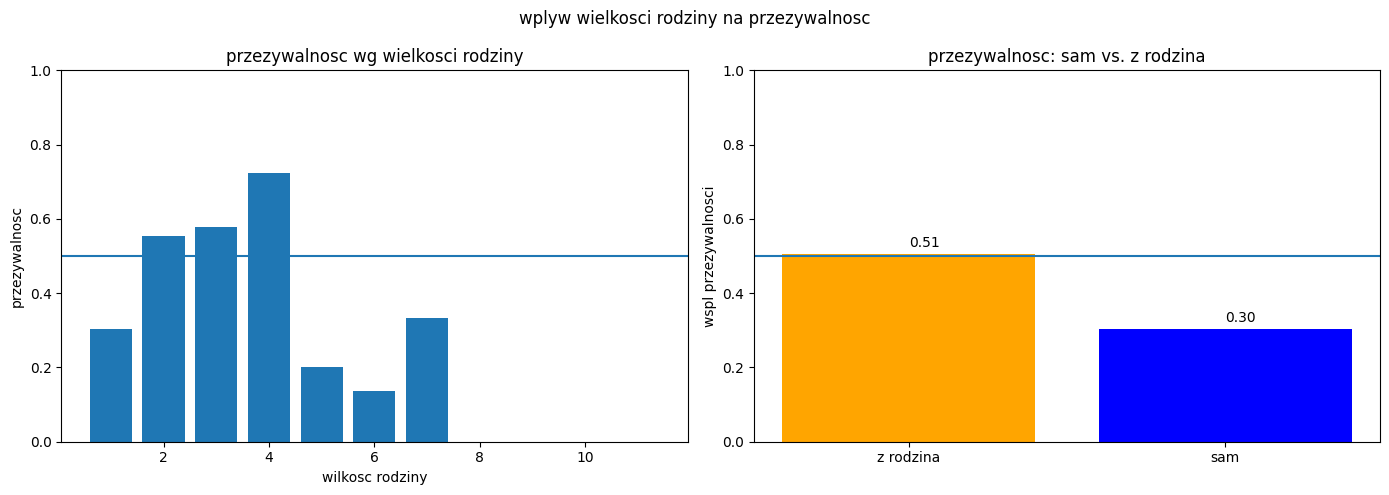

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dforig[dforig['Survived'] == 1]['Age'].hist(
    ax=axes[0], bins=30, color='green', label='przezyl')
dforig[dforig['Survived'] == 0]['Age'].hist(
    ax=axes[0], bins=30, color='red', label='zginal')
axes[0].set_title('rozklad wieku wg przezycia')
axes[0].set_xlabel('wiek')
axes[0].set_ylabel('pasazerowie')
axes[0].legend()

dforig[dforig['Survived'] == 1]['Fare'].hist(
    ax=axes[1], bins=30, color='green', label='przezyl')
dforig[dforig['Survived'] == 0]['Fare'].hist(
    ax=axes[1], bins=30, color='red', label='zinal')
axes[1].set_title('rozklad ceny biletu wg przezycia')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('pasazerowie')
axes[1].legend()

plt.suptitle('przezywalnosc wzgledem cech')
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

familysurv = dforig.groupby('FamilySize')['Survived'].mean()
axes[0].bar(familysurv.index, familysurv.values)
axes[0].set_title('przezywalnosc wg wielkosci rodziny')
axes[0].set_xlabel('wilkosc rodziny')
axes[0].set_ylabel('przezywalnosc')
axes[0].set_ylim(0, 1)
axes[0].axhline(0.5)

alonesurv = dforig.groupby('IsAlone')['Survived'].mean()
axes[1].bar(['z rodzina', 'sam'], alonesurv.values, color=['orange', 'blue'])
axes[1].set_title('przezywalnosc: sam vs. z rodzina')
axes[1].set_ylabel('wspl przezywalnosci')
axes[1].set_ylim(0, 1)
axes[1].axhline(0.5)
for i, v in enumerate(alonesurv.values):
    axes[1].text(i, v+0.02, f'{v:.2f}')

plt.suptitle('wplyw wielkosci rodziny na przezywalnosc')
plt.tight_layout()
plt.show()


zwykle rodziny (2-4) mialy wieksze szanse na przezycie

osoby podrozujuace z rodzina przezywali w 50%, a bez rodziny tylko w 30%

drozszy bilet koreluje z przezyciem

mlode osoby czesciej byly uratowaned

In [45]:
dforig['Deck'] = dforig['Cabin'].str[0].fillna('U')

for col in ['Title', 'Embarked', 'Deck']:
    print(f'\n{col}:')
    counts = dforig[col].value_counts()
    print(counts)
    rare = counts[counts < 10]
    if not rare.empty:
        print(f'rzadkie kategorie (<10 obserwacji): {list(rare.index)}')



Title:
Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

Embarked:
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

Deck:
Deck
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64
rzadkie kategorie (<10 obserwacji): ['G', 'T']


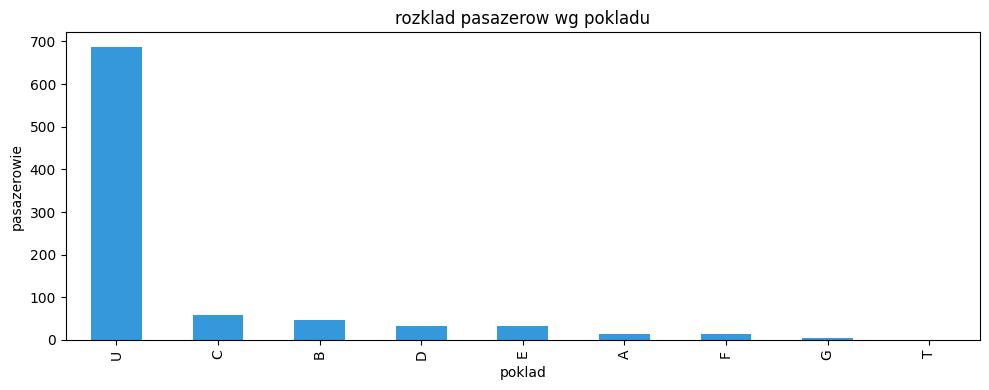

In [46]:
fig, ax = plt.subplots(figsize=(10, 4))
dforig['Deck'].value_counts().plot(kind='bar', ax=ax, color='#3498db')
ax.set_title('rozklad pasazerow wg pokladu')
ax.set_xlabel('poklad')
ax.set_ylabel('pasazerowie')
plt.tight_layout()
plt.show()


macierz korelacji:

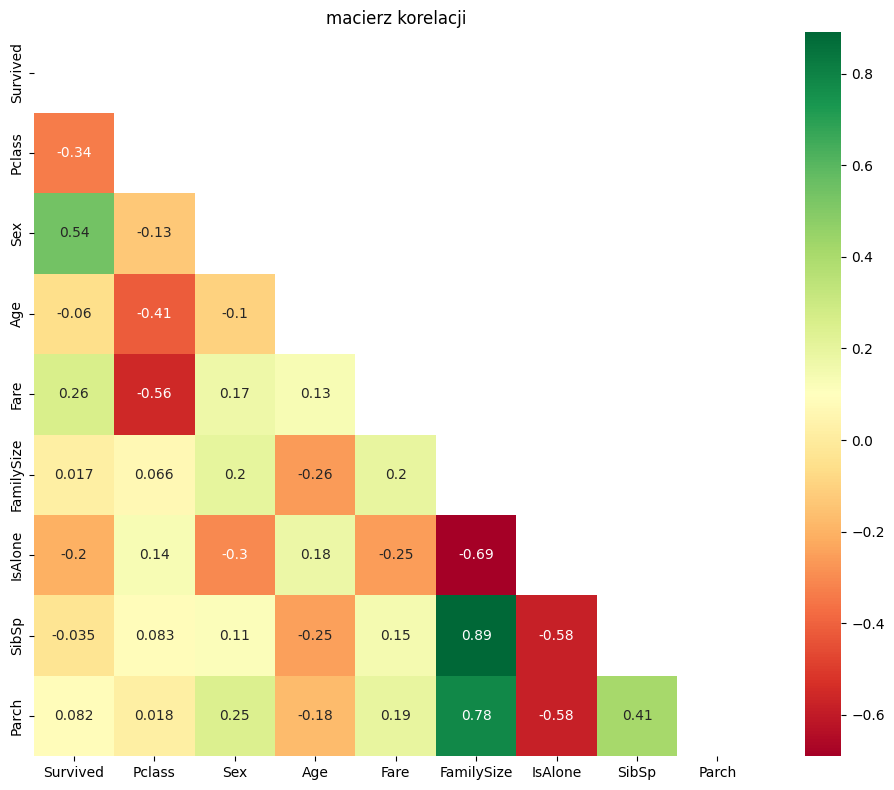

In [47]:
corelmatrix = [
    'Survived',
    'Pclass',
    'Sex',
    'Age',
    'Fare',
    'FamilySize',
    'IsAlone',
    'SibSp',
    'Parch']
coredf = df[corelmatrix].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(coredf, dtype=bool))
sns.heatmap(coredf, mask=mask, annot=True, cmap='RdYlGn', square=True)
plt.title('macierz korelacji')
plt.tight_layout()
plt.show()


widac ze plec (1=kobieta) bardzo koreluje z przezyciem

poza ty im lepsza klasa (i drozszy bilet) tym wieksze szansze przetrwania

wiek nieznacznie koreluje ujemnie z przezywalnoscia

pairplot:

pokazuje zaleznosci miedzy cechami

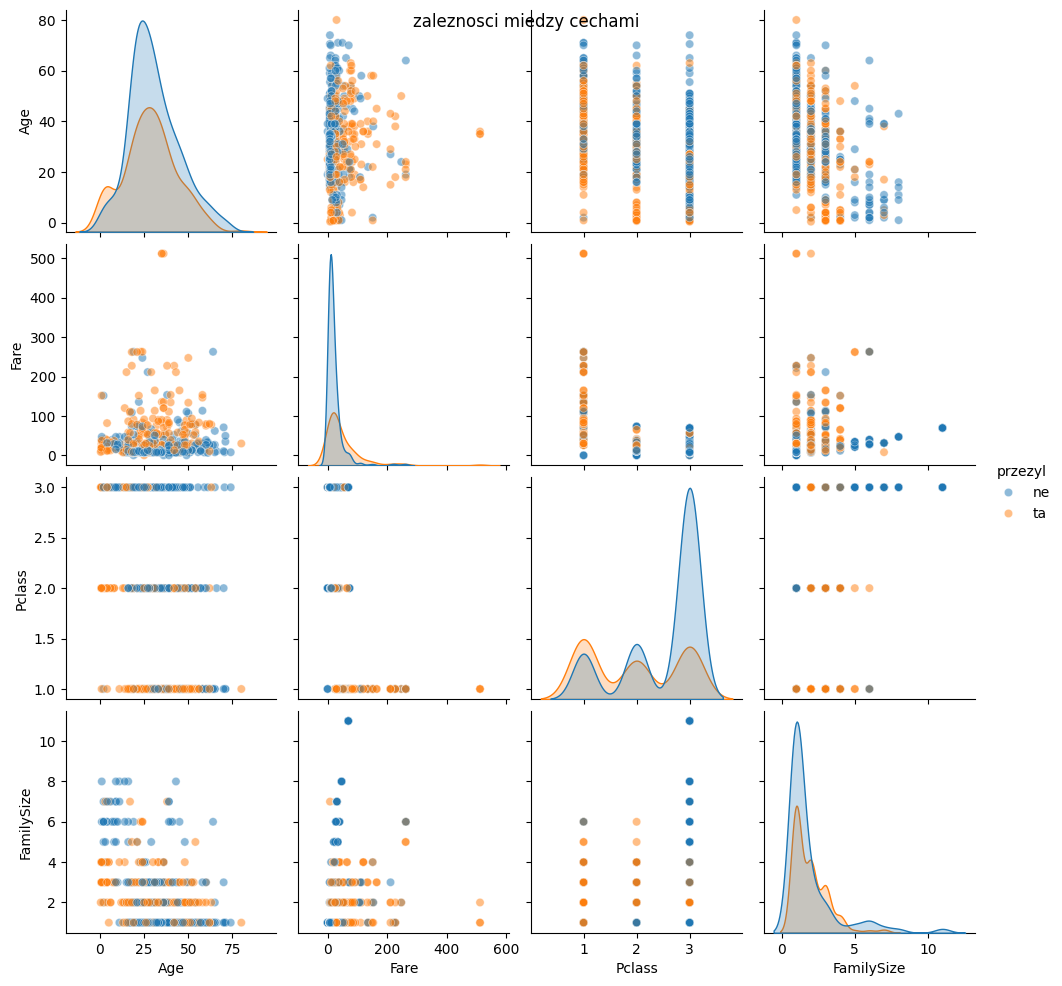

In [48]:
pairvalues = ['Age', 'Fare', 'Pclass', 'FamilySize', 'Survived']
pairdata = dforig[pairvalues].copy()
pairdata['przezyl'] = pairdata['Survived'].map({0: 'ne', 1: 'ta'})

g = sns.pairplot(
    pairdata.drop(
        columns='Survived'),
    hue='przezyl',
    plot_kws={
        'alpha': 0.5})
g.figure.suptitle('zaleznosci miedzy cechami')
plt.show()


Fare i Pclass sa ujemnie skorelowane, wiec mozna powiedziec ze przezyli pasazerowie maja wyzsze Fare i nizsza klase?

4. PODSUMOWANIE

In [49]:
print('finalne wartosci :3')
print(f'ksztalt: {df.shape}')
print(f'brakujace wartosci {df.isnull().sum().sum()}')
print('rozklad Survived::')
print(df['Survived'].value_counts(normalize=True).round(3))
df.head()


finalne wartosci :3
ksztalt: (891, 23)
brakujace wartosci 0
rozklad Survived::
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Embarked_Q,...,Title_Mrs,Title_Rare,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U
PassengerId,,,,,,,,,,,,,,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,2,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1,1,1,38.0,1,0,71.2833,2,0,0,...,1,0,0,1,0,0,0,0,0,0
3,1,3,1,26.0,0,0,7.9250,1,1,0,...,0,0,0,0,0,0,0,0,0,1
4,1,1,1,35.0,1,0,53.1000,2,0,0,...,1,0,0,1,0,0,0,0,0,0
5,0,3,0,35.0,0,0,8.0500,1,1,0,...,0,0,0,0,0,0,0,0,0,1


A wiec najwiekszy wplyw na przezycie miala plec, z korzyscia dla kobet (stanowily ok. 74% uratowanych).

Kolejnym waznym czynnikiem byl status spoleczny (czyli klasa podrozy + cena biletu), bedac w I klasie mialo sie wieksze szanse przezycia niz w II czy III.

Sam tytul osoby stanowi w miare dobry predykat plci i statusu spolecznego poasazera, co dostarczalo dodatkowych / potwierdzalo informacje.

Osoby podrozojace w grupach 2-4 ososby mialy najwieksze szanse na przezycie, w przeciwienstwie do samotnikow czy duzych rodzin.

Ogolnie przezylo tylko ok. 38% osob :( wiec zbior jest niezbalansowany :[